In [3]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [4]:
# Loading dataframes
steam = pd.read_csv("../data/raw/steam.csv")
tags = pd.read_csv("../data/raw/steamspy_tag_data.csv")
desc = pd.read_csv("../data/raw/steam_description_data.csv")
req = pd.read_csv("../data/raw/steam_requirements_data.csv")

In [5]:
steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


# EDA

We can search for the most popular games for now (reviews count and score)

## Future Engineering (Success)

In [6]:
# Total reviews will have both positive and negative ratings in the same column.

steam["total_reviews"] = (
    steam["positive_ratings"] + steam["negative_ratings"]
)

In [7]:
steam["review_score"] = (
    steam["positive_ratings"] / steam["total_reviews"]
)

In [8]:
steam["review_score"] = steam["positive_ratings"] / steam["total_reviews"]

steam["review_score"] = steam["review_score"].fillna(0)

steam["success"] = steam["review_score"] * steam["total_reviews"]

In [9]:
steam["success"]

0        124534.0
1          3318.0
2          3416.0
3          1273.0
4          5250.0
           ...   
27070         3.0
27071         8.0
27072         0.0
27073         2.0
27074         4.0
Name: success, Length: 27075, dtype: float64

In [10]:
steam[["positive_ratings", "negative_ratings", "total_reviews", "review_score", "success"]].head()

,positive_ratings,negative_ratings,total_reviews,review_score,success
0,124534,3339,127873,0.973888,124534.0
1,3318,633,3951,0.839787,3318.0
2,3416,398,3814,0.895648,3416.0
3,1273,267,1540,0.826623,1273.0
4,5250,288,5538,0.947996,5250.0


In [11]:
# Top 10 success games on Steam

steam.sort_values("success", ascending=False).head(10)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,total_reviews,review_score,success
25,730,Counter-Strike: Global Offensive,2012-08-21,1,Valve;Hidden Path Entertainment,Valve,windows;mac;linux,0,Multi-player;Steam Achievements;Full controlle...,Action;Free to Play,...,167,2644404,402313,22494,6502,50000000-100000000,0.00,3046717,0.867952,2644404.0
22,570,Dota 2,2013-07-09,1,Valve,Valve,windows;mac;linux,0,Multi-player;Co-op;Steam Trading Cards;Steam W...,Action;Free to Play;Strategy,...,0,863507,142079,23944,801,100000000-200000000,0.00,1005586,0.858710,863507.0
19,440,Team Fortress 2,2007-10-10,1,Valve,Valve,windows;mac;linux,0,Multi-player;Cross-Platform Multiplayer;Steam ...,Action;Free to Play,...,520,515879,34036,8495,623,20000000-50000000,0.00,549915,0.938107,515879.0
12836,578080,PLAYERUNKNOWN'S BATTLEGROUNDS,2017-12-21,1,PUBG Corporation,PUBG Corporation,windows,0,Multi-player;Online Multi-Player;Stats,Action;Adventure;Massively Multiplayer,...,37,496184,487076,22938,12434,50000000-100000000,26.99,983260,0.504632,496184.0
121,4000,Garry's Mod,2006-11-29,1,Facepunch Studios,Valve,windows;mac;linux,0,Single-player;Multi-player;Co-op;Cross-Platfor...,Indie;Simulation,...,29,363721,16433,12422,1875,10000000-20000000,6.99,380154,0.956773,363721.0
2478,271590,Grand Theft Auto V,2015-04-13,1,Rockstar North,Rockstar Games,windows,18,Single-player;Multi-player;Steam Achievements;...,Action;Adventure,...,77,329061,139308,9837,4834,10000000-20000000,24.99,468369,0.702568,329061.0
1467,218620,PAYDAY 2,2013-08-13,1,OVERKILL - a Starbreeze Studio.,Starbreeze Publishing AB,windows;linux,18,Single-player;Multi-player;Co-op;Online Co-op;...,Action;RPG,...,1130,308657,56523,3975,890,10000000-20000000,7.49,365180,0.845219,308657.0
3362,304930,Unturned,2017-07-07,1,Smartly Dressed Games,Smartly Dressed Games,windows;mac;linux,0,Single-player;Online Multi-Player;Online Co-op...,Action;Adventure;Casual;Free to Play;Indie,...,46,292574,31482,3248,413,20000000-50000000,0.00,324056,0.902850,292574.0
1120,105600,Terraria,2011-05-16,1,Re-Logic,Re-Logic,windows;mac;linux,0,Single-player;Multi-player;Online Multi-Player...,Action;Adventure;Indie;RPG,...,88,255600,7797,5585,1840,5000000-10000000,6.99,263397,0.970398,255600.0
21,550,Left 4 Dead 2,2009-11-19,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Co-op;Steam Achieve...,Action,...,70,251789,8418,1615,566,10000000-20000000,7.19,260207,0.967649,251789.0


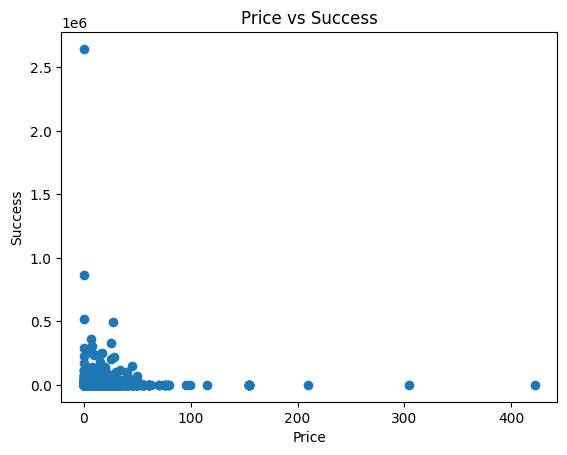

In [12]:
# Success VS Price Plot

plt.scatter(steam["price"], steam["success"])
plt.xlabel("Price")
plt.ylabel("Success")
plt.title("Price vs Success")
plt.show()

In [13]:
steam["success"].describe()

count    2.707500e+04
mean     1.000559e+03
std      1.898872e+04
min      0.000000e+00
25%      6.000000e+00
50%      2.400000e+01
75%      1.260000e+02
max      2.644404e+06
Name: success, dtype: float64

Text(0.5, 1.0, 'Success Distribution')

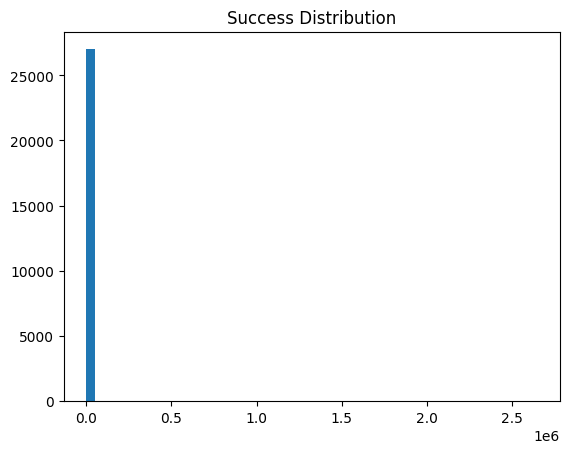

In [14]:
plt.hist(steam["success"], bins=50)
plt.title("Success Distribution")

In [15]:

steam["log_success"] = np.log1p(steam["success"])

Text(0.5, 1.0, 'Log Success Distribution')

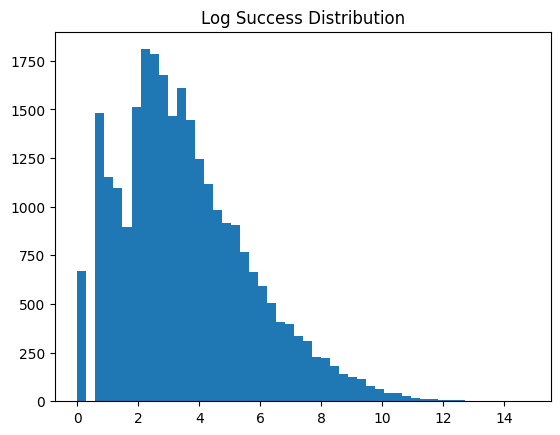

In [16]:
plt.hist(steam["log_success"], bins=50)
plt.title("Log Success Distribution")

The distribution of game success is highly uneven. While most games achieve moderate success, only a small number of titles dominate the platform with very high engagement and visibility.

## Price vs LogSuccess

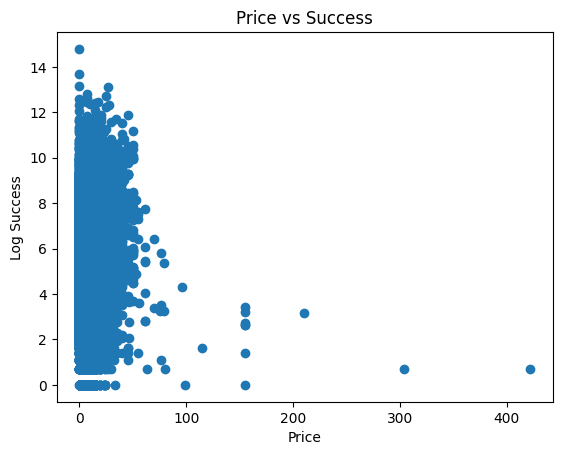

In [17]:

plt.scatter(steam["price"], steam["log_success"])
plt.xlabel("Price")
plt.ylabel("Log Success")
plt.title("Price vs Success")
plt.show()

The majority of Steam games are low-priced or free

The market is heavily concentrated in cheap games

Expensive games are rare and not successful

No linear relationship between price and success, success is spread across prices, but concentrated in cheaper games

## Reviews vs Success

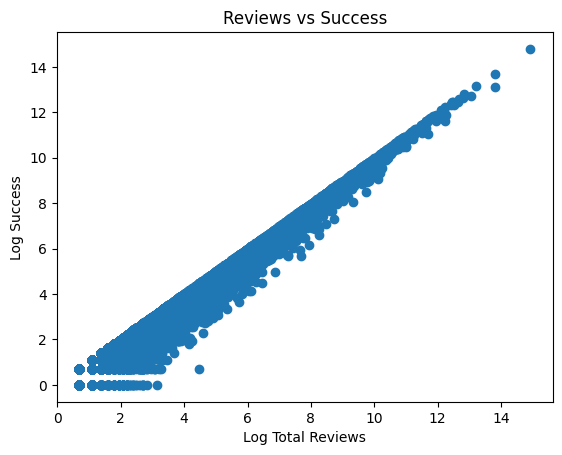

In [18]:
steam["log_reviews"] = np.log1p(steam["total_reviews"])

plt.scatter(steam["log_reviews"], steam["log_success"])
plt.xlabel("Log Total Reviews")
plt.ylabel("Log Success")
plt.title("Reviews vs Success")
plt.show()

There is a strong positive relationship between total reviews and success. This is expected since the success metric includes the number of reviews, highlighting that visibility and player engagement are key drivers of game success.

## Playtime vs Success

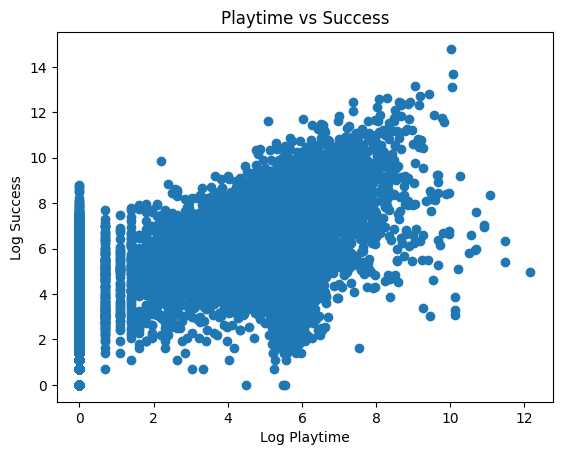

In [19]:
steam["log_playtime"] = np.log1p(steam["average_playtime"])

plt.scatter(steam["log_playtime"], steam["log_success"])
plt.xlabel("Log Playtime")
plt.ylabel("Log Success")
plt.title("Playtime vs Success")
plt.show()

The distribution of success is highly skewed, with most games achieving low to moderate success and a small number of games dominating the platform. A log transformation was applied to better visualize this distribution.

A strong positive relationship was observed between total reviews and success, which is expected since the success metric incorporates the number of reviews. This highlights the importance of visibility and player engagement in driving game performance.

Additionally, games with higher average playtime tend to achieve greater success, suggesting that player retention and engagement are key contributing factors. However, this relationship is less direct than reviews, indicating that multiple factors influence success.

Finally, price does not show a strong correlation with success, suggesting that higher pricing does not necessarily lead to better performance.

------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------

# KPI Definition

To measure game performance, so far Success is define as our main KPI, combining review score (captures customer satisfaction) with total_reviews/review count (This avoids calling a game successful just because it has a high score from only 3-10 reviews.)

In addition to the main KPI, the following supporting KPI's are considered:

* Average Playtime: This is the second main kpi/metric since it covers client engagement, retention and can also increase profit if the game has/could have in-game purchases, even when it's a free-to-play game.

* Price is treated as a strategic business variable rather than a direct KPI. It represents the game’s monetization strategy and is used to explore its impact on success and engagement, the following questions will be explored:

    * Do cheaper games receive more reviews?

    * Is there an optimal price range that maximizes success?

    * Do free-to-play games achieve higher engagement?

    * Are premium-priced games associated with higher or lower review scores? 

--------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------

# Hypothesis

To understand what drives success on Steam, we test the following hypothesis:

* H1: Lower-priced games achieve higher success than high-priced games.
* H2: Games with more reviews tend to achieve higher success.
* H3: Games with higher average playtime tend to be more successful.
* H4: Game success on Steam is highly concentrated among small number of titles.
* H5: There is an optimal price range that maximizes game success.

This hypothesis testing will be done in SQL, to do this I need to create a cleaned dataframe that contains all the columns needed 
(steam.csv original columns + columns created for EDA).

In [20]:
steam.to_csv("../data/processed/steam_cleaned.csv", index= False)